# BMI analysis: clustering, isolation forest & trends

Structured notebook: each section has a **markdown title**; code is split so you can run top-to-bottom.

## 0. Imports & settings

In [12]:
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable
  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\ratha\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\ratha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from prophet import Prophet
from IPython.display import display

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Load raw data

In [14]:
DATA_PATH = r"F:\St. Clair\Sem 4\Capstone Project\DAta\BMI_Data.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(29918, 26)

## 2. Clean data & build features

In [15]:
df = df.copy()
for col in ["BMI_Value", "CI_Low", "CI_High", "Year"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["CI_Range"] = df["CI_High"] - df["CI_Low"]

adults = df.dropna(
    subset=["Year", "BMI_Value", "CI_Range", "CountryCode", "Region"]
).copy()

adults.head()

,RecordID,Indicator,LocationType,CountryCode,RegionCode,Region,TimeType,Year,SexType,Sex,...,BMI_Value,CI_Low,CI_High,Comments,ReportDate,YearValue,YearStart,YearEnd,Unnamed: 25,CI_Range
0,19333,NCD_BMI_18A,COUNTRY,CIV,AFR,Africa,YEAR,2004,SEX,SEX_BTSX,...,10.1,7.8,12.7,NaN,2024-02-29T16:06:41Z,2004,01-01-2004,31-12-2004,1,4.9
1,238780,NCD_BMI_18A,COUNTRY,GHA,AFR,Africa,YEAR,2006,SEX,SEX_BTSX,...,10.1,8.8,11.6,NaN,2024-02-29T16:06:41Z,2006,01-01-2006,31-12-2006,2,2.8
2,688218,NCD_BMI_18A,COUNTRY,SWZ,AFR,Africa,YEAR,1995,SEX,SEX_MLE,...,10.1,5.9,15.2,NaN,2024-02-29T16:06:41Z,1995,01-01-1995,31-12-1995,3,9.3
3,721118,NCD_BMI_18A,COUNTRY,TZA,AFR,Africa,YEAR,2016,SEX,SEX_FMLE,...,10.1,8.1,12.3,NaN,2024-02-29T16:06:41Z,2016,01-01-2016,31-12-2016,4,4.2
4,839591,NCD_BMI_18A,COUNTRY,DZA,AFR,Africa,YEAR,1991,SEX,SEX_MLE,...,10.1,6.3,15.0,NaN,2024-02-29T16:06:41Z,1991,01-01-1991,31-12-1991,5,8.7


## 3. K-Means risk groups (baseline: *k* = 3)

Three clusters are interpreted as low / medium / high BMI risk for the latest survey year.

In [16]:
latest_year = int(adults["Year"].max())
latest = adults[adults["Year"] == latest_year].copy()

X_cluster = latest[["BMI_Value", "CI_Range"]].dropna()
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(X_cluster)

kmeans_baseline = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
latest.loc[X_cluster.index, "Cluster"] = kmeans_baseline.fit_predict(X_scaled)

order = latest.groupby("Cluster")["BMI_Value"].mean().sort_values().index.tolist()
risk_names = {order[0]: "Low Risk", order[1]: "Medium Risk", order[2]: "High Risk"}
latest["Risk_Group"] = latest["Cluster"].map(risk_names)

latest[["Year", "Region", "CountryCode", "Sex", "BMI_Value", "CI_Range", "Risk_Group"]].head(10)

,Year,Region,CountryCode,Sex,BMI_Value,CI_Range,Risk_Group
18,2022,Africa,RWA,SEX_BTSX,10.1,4.3,Low Risk
27,2022,Africa,GIN,SEX_BTSX,10.1,7.8,Low Risk
76,2022,Americas,HTI,SEX_FMLE,10.1,7.4,Low Risk
92,2022,Eastern Mediterranean,YEM,SEX_MLE,10.1,9.8,Low Risk
127,2022,Western Pacific,PHL,SEX_FMLE,10.1,6.6,Low Risk
136,2022,Western Pacific,LAO,SEX_FMLE,10.1,8.0,Low Risk
163,2022,Africa,GNB,SEX_MLE,10.2,17.8,Medium Risk
211,2022,Africa,NAM,SEX_MLE,10.2,10.9,Low Risk
215,2022,Africa,SEN,SEX_BTSX,10.2,4.6,Low Risk
258,2022,South-East Asia,NPL,SEX_FMLE,10.2,4.9,Low Risk


### 3.1 Scatter: BMI vs CI range (coloured by cluster)

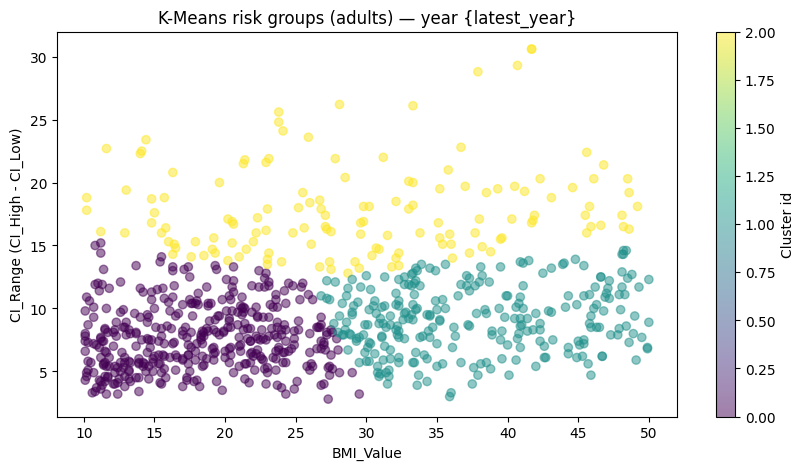

In [17]:
plt.scatter(latest["BMI_Value"], latest["CI_Range"], c=latest["Cluster"], alpha=0.5)
plt.xlabel("BMI_Value")
plt.ylabel("CI_Range (CI_High - CI_Low)")
plt.title(f"K-Means risk groups (adults) — year {{latest_year}}")
plt.colorbar(label="Cluster id")
plt.show()

## 4. Exploratory trend analysis

### 4.1 Global mean BMI by year

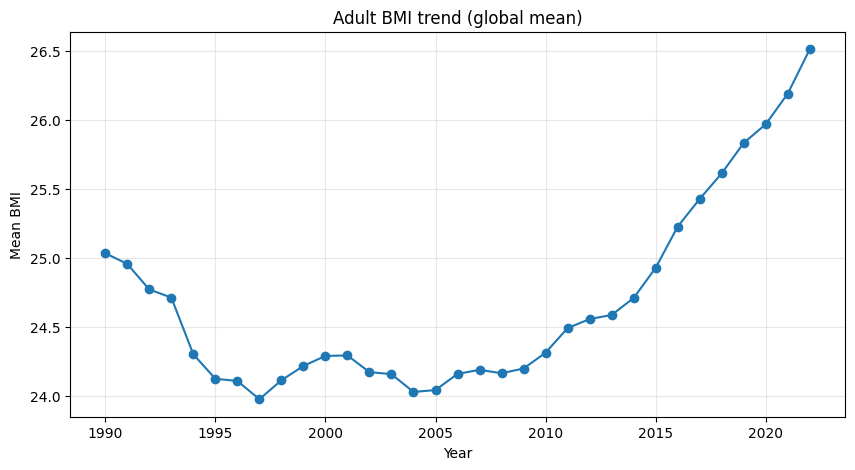

In [18]:
yearly = adults.groupby("Year", as_index=False)["BMI_Value"].mean()

plt.plot(yearly["Year"], yearly["BMI_Value"], marker="o")
plt.xlabel("Year")
plt.ylabel("Mean BMI")
plt.title("Adult BMI trend (global mean)")
plt.grid(True, alpha=0.3)
plt.show()

### 4.2 Summary statistics

In [19]:
adults["BMI_Value"].describe()

count    28017.000000
mean        24.660281
std         11.519153
min         10.100000
25%         15.100000
50%         21.100000
75%         32.800000
max         50.000000
Name: BMI_Value, dtype: float64

### 4.3 BMI by sex and by region

In [20]:
display(
    adults.groupby("Sex")["BMI_Value"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(
    adults.groupby("Region")["BMI_Value"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .to_frame("mean_BMI")
)

,count,mean,median,std,min,max
Sex,,,,,,
SEX_FMLE,9812,26.292988,23.5,11.803689,10.1,50.0
SEX_BTSX,9499,24.512359,21.0,11.479129,10.1,50.0
SEX_MLE,8706,22.981553,19.3,10.972664,10.1,50.0


,mean_BMI
Region,
Americas,27.826044
Western Pacific,27.275777
Europe,26.756689
Eastern Mediterranean,26.000990
South-East Asia,21.986884
Africa,20.030900


### 4.4 Male vs female (Welch *t*-test)

In [21]:
male = adults.loc[adults["Sex"] == "SEX_MLE", "BMI_Value"].dropna()
female = adults.loc[adults["Sex"] == "SEX_FMLE", "BMI_Value"].dropna()

t_stat, p_val = ttest_ind(male, female, equal_var=False)

print("Welch t-test (male vs female)")
print("male n =", len(male))
print("female n =", len(female))
print("t =", t_stat)
print("p =", p_val)

Welch t-test (male vs female)
male n = 8706
female n = 9812
t = -19.77932501165679
p = 3.494499277489751e-86


## 5. Isolation Forest — anomaly detection (adults)

### 5.1 Helper: fit model & attach labels

In [22]:
adult_df = df.loc[df["Indicator"] == "NCD_BMI_25A"].copy()
print("Adult rows (indicator filter):", adult_df.shape)


def detect_anomalies(data, contamination=0.03, n_estimators=200):
    features = data[["BMI_Value", "Year", "CI_Low", "CI_High"]].dropna()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(features)
    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )
    model.fit(Xs)
    out = data.loc[features.index].copy()
    out["Anomaly"] = model.predict(Xs)
    return out


adult_results = detect_anomalies(adult_df)
adult_anomalies = adult_results[adult_results["Anomaly"] == -1]
print("Anomalies flagged:", adult_anomalies.shape[0])

Adult rows (indicator filter): (11147, 27)
Anomalies flagged: 335


### 5.2 Regions & countries with the most anomalies

In [23]:
region_rank = adult_anomalies.groupby("Region").size().sort_values(ascending=False)
print("Top regions by anomaly count:\n", region_rank)

country_rank = (
    adult_anomalies.groupby("CountryCode")["BMI_Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop countries by mean BMI among anomalous points:\n", country_rank)

Top regions by anomaly count:
 Region
Africa                   143
Americas                  51
South-East Asia           42
Europe                    37
Eastern Mediterranean     31
Western Pacific           15
dtype: int64

Top countries by mean BMI among anomalous points:
 CountryCode
MUS    50.00
IRL    50.00
ESP    49.90
BLR    49.90
KNA    49.90
MDV    49.90
TTO    49.90
PRI    49.90
PAK    49.90
FIN    49.85
Name: BMI_Value, dtype: float64


### 5.3 Scatter: years vs BMI (normal vs anomaly)

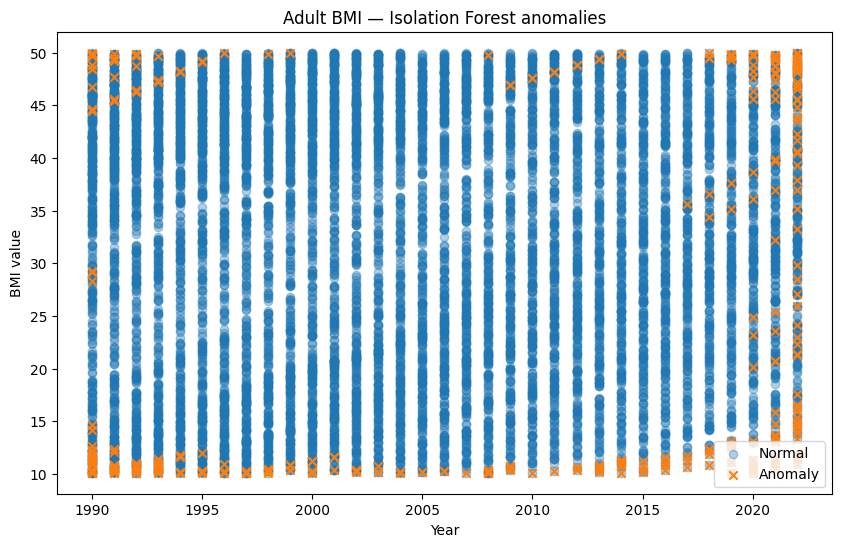

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(adult_results["Year"], adult_results["BMI_Value"], alpha=0.35, label="Normal")
plt.scatter(adult_anomalies["Year"], adult_anomalies["BMI_Value"], marker="x", label="Anomaly")
plt.title("Adult BMI — Isolation Forest anomalies")
plt.xlabel("Year")
plt.ylabel("BMI value")
plt.legend()
plt.show()

### Interpretation (Isolation Forest chart)

Most BMI values follow a smooth global pattern over time. Points marked as anomalies are unusually high or low relative to the model; they may reflect unusual country-year patterns worth a closer look.

## 6. Prophet — long-horizon forecast (global mean BMI)

13:07:02 - cmdstanpy - INFO - Chain [1] start processing
13:07:06 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\ratha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\prophet\forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


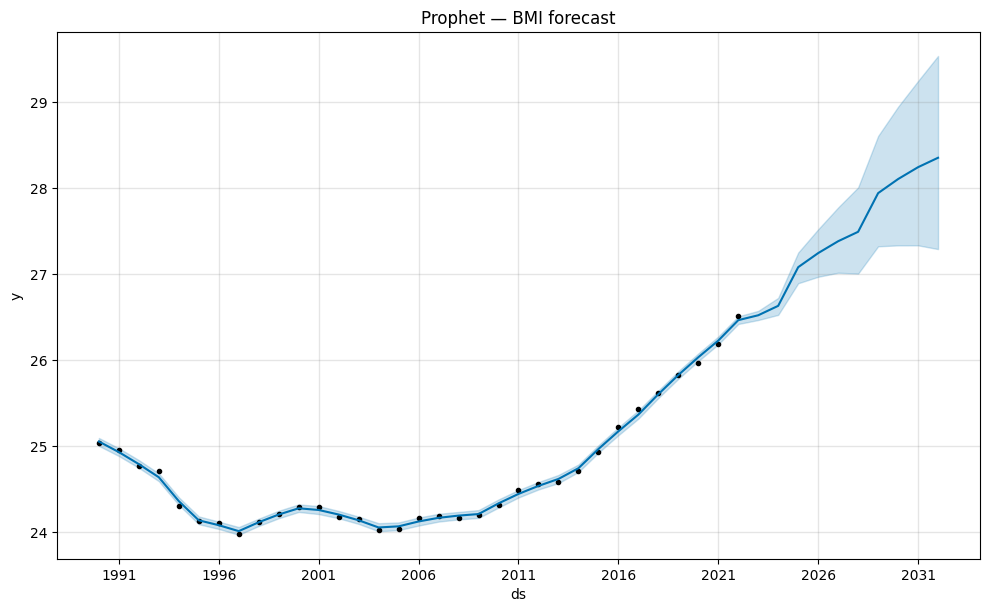

In [25]:
prophet_df = pd.DataFrame(
    {"ds": pd.to_datetime(yearly["Year"], format="%Y"), "y": yearly["BMI_Value"]}
)
prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=10, freq="Y")
forecast = prophet_model.predict(future)
prophet_model.plot(forecast)
plt.title("Prophet — BMI forecast")
plt.show()

## 7. ML insights — summary tables & CSV export

Uses the **baseline** *k* = 3 clustering and default Isolation Forest settings above.

In [26]:
risk_counts = latest["Risk_Group"].value_counts().reset_index()
risk_counts.columns = ["Risk_Group", "Count"]

region_bmi_latest = (
    latest.groupby("Region", as_index=False)["BMI_Value"].mean()
    .sort_values("BMI_Value", ascending=False)
)

region_anomaly_counts = (
    adult_anomalies.groupby("Region").size().reset_index(name="Anomaly_Count")
    .sort_values("Anomaly_Count", ascending=False)
)

top_countries = (
    adult_anomalies.groupby("CountryCode")["BMI_Value"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(risk_counts)
print(region_bmi_latest.head())
print(region_anomaly_counts.head())

risk_counts.to_csv("week8_risk_group_counts.csv", index=False)
region_bmi_latest.to_csv("week8_region_bmi_latest.csv", index=False)
yearly.to_csv("week8_yearly_bmi_trend.csv", index=False)
region_anomaly_counts.to_csv("week8_region_anomaly_counts.csv", index=False)
top_countries.to_csv("week8_top_anomalous_countries.csv", index=False)
print("\nSaved week8_*.csv")

    Risk_Group  Count
0     Low Risk    397
1    High Risk    264
2  Medium Risk    139
                  Region  BMI_Value
1               Americas  31.834167
2  Eastern Mediterranean  29.418182
5        Western Pacific  27.846835
3                 Europe  27.283158
4        South-East Asia  23.482258
                  Region  Anomaly_Count
0                 Africa            143
1               Americas             51
4        South-East Asia             42
3                 Europe             37
2  Eastern Mediterranean             31

Saved week8_*.csv


## 8. Hyperparameter tuning — K-Means

Sweep *k* and compare **silhouette**, **Davies–Bouldin**, **Calinski–Harabasz**, and **inertia** (elbow).

   k  silhouette_score  davies_bouldin_score  calinski_harabasz_score  \
0  2          0.409862              1.027045               587.926169   
1  3          0.422007              0.879582               678.752716   
2  4          0.382668              0.866695               641.085411   
3  5          0.369632              0.858158               652.806465   
4  6          0.379254              0.840095               657.662745   

      inertia  
0  921.261196  
1  591.875974  
2  468.363365  
3  373.433839  
4  311.196073  

Best k (max silhouette): 3


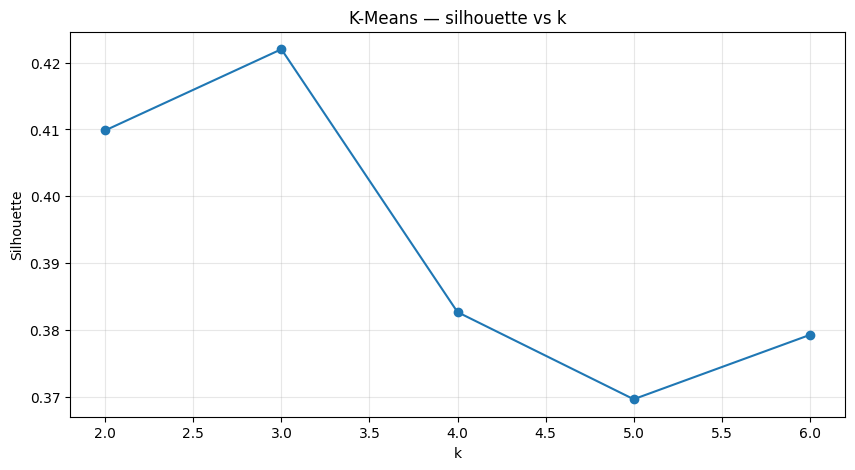

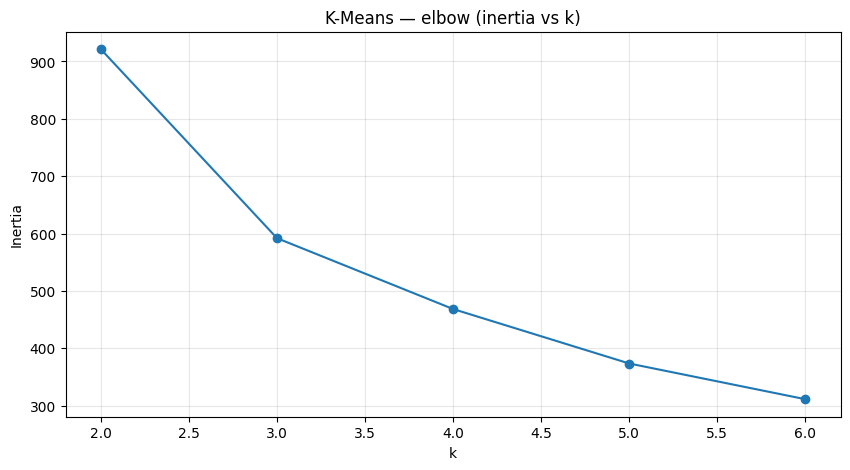

In [27]:
latest_tune = adults[adults["Year"] == adults["Year"].max()].copy()
X_k = latest_tune[["BMI_Value", "CI_Range"]].dropna()
scaler_k = StandardScaler()
Xk_scaled = scaler_k.fit_transform(X_k)

rows = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Xk_scaled)
    rows.append(
        {
            "k": k,
            "silhouette_score": silhouette_score(Xk_scaled, labels),
            "davies_bouldin_score": davies_bouldin_score(Xk_scaled, labels),
            "calinski_harabasz_score": calinski_harabasz_score(Xk_scaled, labels),
            "inertia": km.inertia_,
        }
    )

kmeans_tuning_df = pd.DataFrame(rows)
print(kmeans_tuning_df)

best_k = int(kmeans_tuning_df.loc[kmeans_tuning_df["silhouette_score"].idxmax(), "k"])
print("\nBest k (max silhouette):", best_k)

plt.plot(kmeans_tuning_df["k"], kmeans_tuning_df["silhouette_score"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("K-Means — silhouette vs k")
plt.grid(True, alpha=0.3)
plt.show()

plt.plot(kmeans_tuning_df["k"], kmeans_tuning_df["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("K-Means — elbow (inertia vs k)")
plt.grid(True, alpha=0.3)
plt.show()

## 9. Hyperparameter tuning — Isolation Forest

Grid over `contamination` and `n_estimators`. The **best** row is the one whose anomaly rate is closest to the target **3%** (adjust `TARGET_ANOMALY_RATE` if you prefer).

In [28]:
features_if = adult_df[["BMI_Value", "Year", "CI_Low", "CI_High"]].dropna()
scaler_if = StandardScaler()
X_if_scaled = scaler_if.fit_transform(features_if)

TARGET_ANOMALY_RATE = 0.03
iso_rows = []
for contamination in (0.01, 0.03, 0.05):
    for n_estimators in (100, 200, 300):
        iso = IsolationForest(
            contamination=contamination,
            n_estimators=n_estimators,
            random_state=RANDOM_STATE,
        )
        preds = iso.fit_predict(X_if_scaled)
        rate = (preds == -1).mean()
        iso_rows.append(
            {
                "contamination": contamination,
                "n_estimators": n_estimators,
                "anomaly_count": int((preds == -1).sum()),
                "anomaly_rate": rate,
            }
        )

iso_tuning_df = pd.DataFrame(iso_rows)
iso_tuning_df["gap_to_target"] = (iso_tuning_df["anomaly_rate"] - TARGET_ANOMALY_RATE).abs()
print(iso_tuning_df.sort_values("gap_to_target"))

best_idx = iso_tuning_df["gap_to_target"].idxmin()
best_c = float(iso_tuning_df.loc[best_idx, "contamination"])
best_n = int(iso_tuning_df.loc[best_idx, "n_estimators"])
print(f"\nChosen: contamination={{best_c}}, n_estimators={{best_n}}")

best_iso_model = IsolationForest(
    contamination=best_c, n_estimators=best_n, random_state=RANDOM_STATE
)
best_iso_preds = best_iso_model.fit_predict(X_if_scaled)
adult_df_tuned = adult_df.loc[features_if.index].copy()
adult_df_tuned["Anomaly"] = best_iso_preds

   contamination  n_estimators  anomaly_count  anomaly_rate  gap_to_target
3           0.03           100            335      0.030053       0.000053
4           0.03           200            335      0.030053       0.000053
5           0.03           300            335      0.030053       0.000053
0           0.01           100            112      0.010048       0.019952
2           0.01           300            112      0.010048       0.019952
1           0.01           200            112      0.010048       0.019952
6           0.05           100            558      0.050058       0.020058
7           0.05           200            558      0.050058       0.020058
8           0.05           300            558      0.050058       0.020058

Chosen: contamination={best_c}, n_estimators={best_n}


## 10. Hyperparameter tuning — trend model (time-based train / test)

Train on all but the **last 5** years; test on those 5. Metrics are stored for the evaluation section.

{'MAE': 1.393361386984553, 'RMSE': 1.4235427758488053, 'R2': -20.389828712013887}


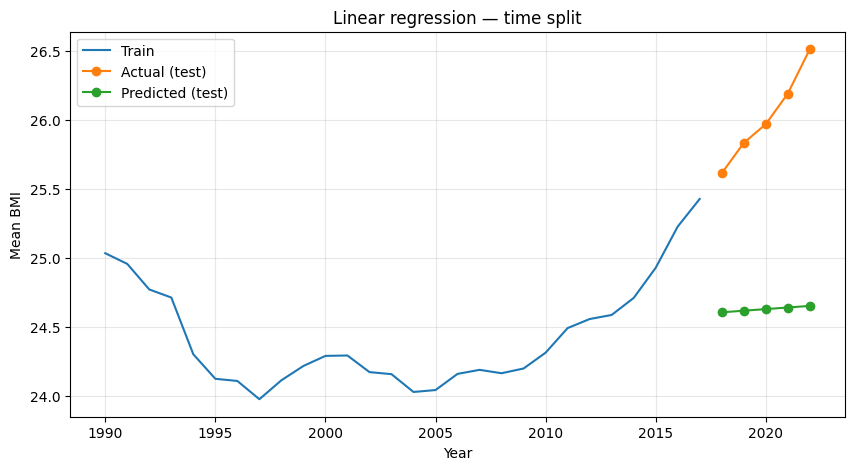


Saved week9_*.csv


In [29]:
train = yearly.iloc[:-5].copy()
test = yearly.iloc[-5:].copy()

X_train, y_train = train[["Year"]], train["BMI_Value"]
X_test, y_test = test[["Year"]], test["BMI_Value"]

linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

LR_TEST_RESULTS = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred))),
    "R2": r2_score(y_test, y_pred),
}
print(LR_TEST_RESULTS)

plt.plot(train["Year"], train["BMI_Value"], label="Train")
plt.plot(test["Year"], y_test.values, marker="o", label="Actual (test)")
plt.plot(test["Year"], y_pred, marker="o", label="Predicted (test)")
plt.xlabel("Year")
plt.ylabel("Mean BMI")
plt.title("Linear regression — time split")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

kmeans_tuning_df.to_csv("week9_kmeans_tuning_results.csv", index=False)
iso_tuning_df.drop(columns=["gap_to_target"], errors="ignore").to_csv(
    "week9_isolation_forest_tuning_results.csv", index=False
)
pd.DataFrame([{"model": "LinearRegression", **LR_TEST_RESULTS}]).to_csv(
    "week9_trend_model_evaluation.csv", index=False
)
print("\nSaved week9_*.csv")

## 11. Evaluation metrics — K-Means (tuned *k*)

In [30]:
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
final_labels = km_final.fit_predict(Xk_scaled)

kmeans_eval_df = pd.DataFrame(
    [
        {
            "Model": "KMeans",
            "Best_k": best_k,
            "Silhouette_Score": silhouette_score(Xk_scaled, final_labels),
            "Davies_Bouldin_Score": davies_bouldin_score(Xk_scaled, final_labels),
            "Calinski_Harabasz_Score": calinski_harabasz_score(Xk_scaled, final_labels),
        }
    ]
)
print(kmeans_eval_df)

    Model  Best_k  Silhouette_Score  Davies_Bouldin_Score  \
0  KMeans       3          0.422007              0.879582   

   Calinski_Harabasz_Score  
0               678.752716  


## 12. Evaluation metrics — Isolation Forest (tuned)

             Model  contamination  n_estimators  Total_Records  Anomaly_Count  \
0  IsolationForest           0.03           100          11147            335   

   Anomaly_Rate  
0      0.030053  
                  Region  Anomaly_Ratio
4        South-East Asia       0.046083
0                 Africa       0.039794
2  Eastern Mediterranean       0.039752
1               Americas       0.033046
5        Western Pacific       0.016551


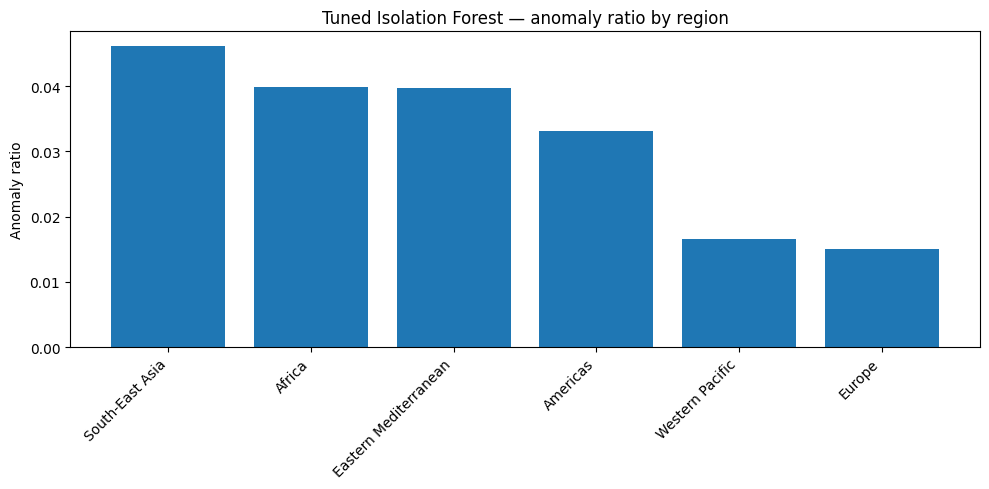

In [31]:
n = len(adult_df_tuned)
anom = int((adult_df_tuned["Anomaly"] == -1).sum())
iso_eval_df = pd.DataFrame(
    [
        {
            "Model": "IsolationForest",
            "contamination": best_c,
            "n_estimators": best_n,
            "Total_Records": n,
            "Anomaly_Count": anom,
            "Anomaly_Rate": anom / n,
        }
    ]
)
print(iso_eval_df)

region_ratio = (
    adult_df_tuned.groupby("Region")["Anomaly"]
    .apply(lambda s: (s == -1).mean())
    .reset_index(name="Anomaly_Ratio")
    .sort_values("Anomaly_Ratio", ascending=False)
)
print(region_ratio.head())

plt.bar(region_ratio["Region"], region_ratio["Anomaly_Ratio"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Anomaly ratio")
plt.title("Tuned Isolation Forest — anomaly ratio by region")
plt.tight_layout()
plt.show()

## 13. Evaluation metrics — trend model & combined comparison

In [32]:
trend_eval_df = pd.DataFrame([{"Model": "LinearRegression_Trend", **LR_TEST_RESULTS}])
print(trend_eval_df)

comparison_df = pd.concat(
    [kmeans_eval_df, iso_eval_df, trend_eval_df], ignore_index=True, sort=False
)
print("\nCombined table:\n", comparison_df)

comparison_df.to_csv("week10_model_comparison.csv", index=False)
region_ratio.to_csv("week10_region_anomaly_ratio.csv", index=False)
kmeans_eval_df.to_csv("week10_kmeans_evaluation.csv", index=False)
iso_eval_df.to_csv("week10_isolation_forest_evaluation.csv", index=False)
trend_eval_df.to_csv("week10_trend_evaluation.csv", index=False)
print("\nSaved week10_*.csv")

                    Model       MAE      RMSE         R2
0  LinearRegression_Trend  1.393361  1.423543 -20.389829

Combined table:
                     Model  Best_k  Silhouette_Score  Davies_Bouldin_Score  \
0                  KMeans     3.0          0.422007              0.879582   
1         IsolationForest     NaN               NaN                   NaN   
2  LinearRegression_Trend     NaN               NaN                   NaN   

   Calinski_Harabasz_Score  contamination  n_estimators  Total_Records  \
0               678.752716            NaN           NaN            NaN   
1                      NaN           0.03         100.0        11147.0   
2                      NaN            NaN           NaN            NaN   

   Anomaly_Count  Anomaly_Rate       MAE      RMSE         R2  
0            NaN           NaN       NaN       NaN        NaN  
1          335.0      0.030053       NaN       NaN        NaN  
2            NaN           NaN  1.393361  1.423543 -20.389829  

Saved